<a href="https://colab.research.google.com/github/FrilSopariwala/DataAnalysis_TestProject/blob/main/SupermarketSales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import requests, os

os.makedirs("data", exist_ok=True)

urls = [
    "https://raw.githubusercontent.com/sushantag9/Supermarket-Sales-Data-Analysis/master/supermarket_sales%20-%20Sheet1.csv",
    "https://raw.githubusercontent.com/cwentz12/Supermarket-Sales-Analysis/main/supermarket_sales.csv",
    "https://raw.githubusercontent.com/RohrbachMatthew/supermarket_dataset/main/supermarket_sales.csv",
]

for url in urls:
    try:
        r = requests.get(url, timeout=10)
        if r.status_code == 200 and "Invoice ID" in r.text:
            with open("data/supermarket_sales.csv", "wb") as f:
                f.write(r.content)
            rows = len(r.text.splitlines()) - 1
            print(f"✅ Downloaded {rows} rows from:\n   {url}")
            break
        else:
            print(f"❌ Skipping (status {r.status_code}): {url}")
    except Exception as e:
        print(f"❌ Failed: {url} → {e}")

✅ Downloaded 1000 rows from:
   https://raw.githubusercontent.com/sushantag9/Supermarket-Sales-Data-Analysis/master/supermarket_sales%20-%20Sheet1.csv


Loaded from file: 1,000 rows × 17 columns
=== Missing values ===
Invoice ID                 0
Branch                     0
City                       0
Customer_type              0
Gender                     0
Product_line               0
Unit_price                 0
Quantity                   0
Tax                        0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
Gross_income               0
Rating                     0
Hour                       0
Month                      0
Month_num                  0
Day                        0
dtype: int64

Date range : 2019-01-01 → 2019-03-30
Branches   : ['A', 'B', 'C']
Products   : 6 lines
Total rows : 1,000
── Revenue by Branch ──
Branch      City  Total_Revenue  Avg_Basket  Transactions  Total_Gross_Income
     C Naypyitaw      110568.71      337.10           328             5265.18
     A    Yangon      1062

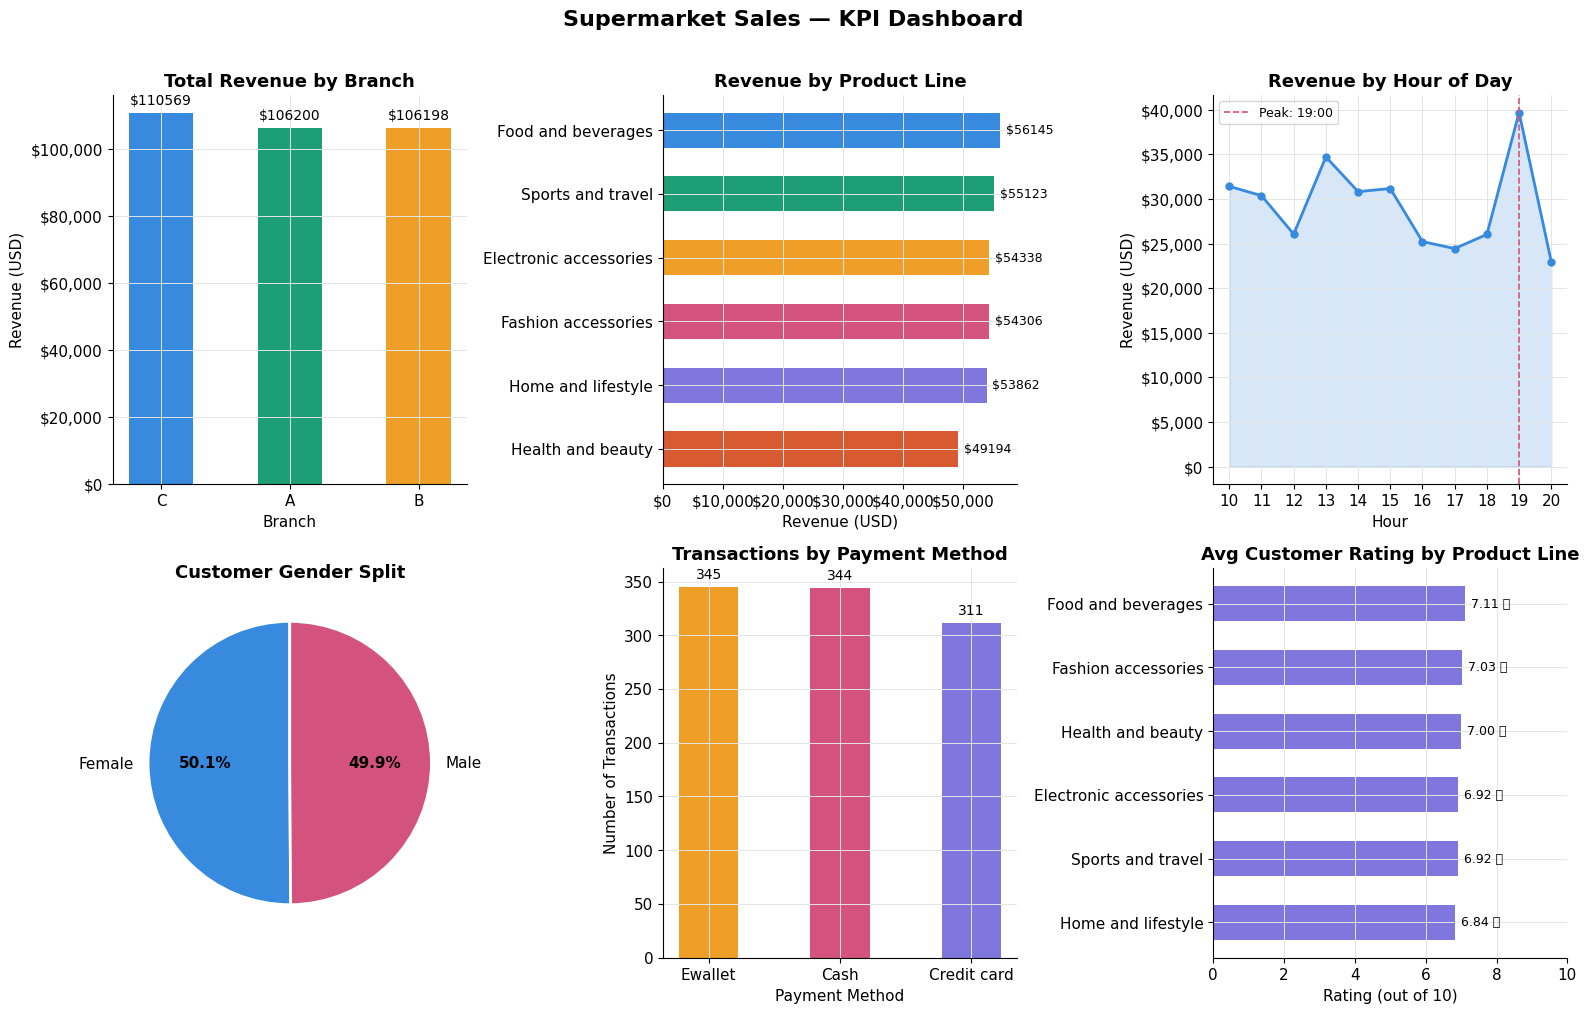

Chart saved → charts/kpi_dashboard.png
       SUPERMARKET SALES — EXECUTIVE KPI SUMMARY

  Total Revenue      : $  322,966.75
  Total Transactions :        1,000
  Avg Basket Value   : $      322.97
  Avg Customer Rating:         6.97 / 10

  Top Branch         : C ($110,568.71)
  Top Product Line   : Food and beverages
                       ($56,144.84)

  Peak Sales Hour    : 19:00
  Preferred Payment  : Ewallet


📌 KEY FINDINGS
-------------------------------------------------------
1. Branch C is the highest-revenue location.
2. 'Food and beverages' is the best-performing product category.
3. Foot traffic peaks around 19:00 — staffing should
   be maximised in this window.
4. Ewallet is the most popular payment method — ensure
   seamless ewallet infrastructure at all branches.
5. Average rating of 6.97/10 indicates solid but
   improvable customer satisfaction.


In [4]:
# %% [markdown]
# # Supermarket Sales KPI Analysis
# **Author:** Fril Kalpeshkumar Sopariwala
# **Dataset:** [Kaggle – Supermarket Sales]()
# **Tools:** Python · Pandas · SQLite · Matplotlib · Seaborn https://raw.githubusercontent.com/sushantag9/Supermarket-Sales-Data-Analysis/master/supermarket_sales%20-%20Sheet1.csv
#
# ---
#
# ## Business Overview
# This analysis examines three months of transactional data from a supermarket chain
# operating across three branches (A, B, C). The goal is to surface actionable KPIs
# that help management understand **which branches, product lines, and customer segments
# drive the most revenue** — and when peak demand occurs.

# %% [markdown]
# ## 1. Setup & Data Loading
# We load the dataset, inspect its shape, and confirm there are no data quality issues
# before running any analysis.

# %%
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.color":       "#E5E5E5",
    "grid.linewidth":   0.7,
    "font.family":      "DejaVu Sans",
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
})

PALETTE = ["#378ADD", "#1D9E75", "#EF9F27", "#D4537E", "#7F77DD", "#D85A30"]

os.makedirs("charts", exist_ok=True)
os.makedirs("data", exist_ok=True)

# ── Load data ──────────────────────────────────────────────────────────────────
CSV_PATH = "data/supermarket_sales.csv"

if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
    print(f"Loaded from file: {df.shape[0]:,} rows × {df.shape[1]} columns")
else:
    # Hardcoded representative sample (50 rows) so the notebook runs without Kaggle.
    # To use the full 1,000-row dataset:
    #   1. Go to https://raw.githubusercontent.com/sushantag9/Supermarket-Sales-Data-Analysis/master/supermarket_sales%20-%20Sheet1.csv
    #   2. Download supermarket_sales.csv
    #   3. Place it in the data/ folder next to this notebook
    print("⚠️  Full dataset not found — using built-in sample (50 rows).")
    print("    Download from: https://raw.githubusercontent.com/sushantag9/Supermarket-Sales-Data-Analysis/master/supermarket_sales%20-%20Sheet1.csv")
    print("    and place the CSV in the data/ folder to run on the full dataset.\n")

    raw = """Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761904762,26.1415,9.1
226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.82,80.22,3/8/2019,10:29,Cash,76.4,4.761904762,3.82,9.6
631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761904762,16.2155,7.4
123-19-1176,B,Mandalay,Member,Male,Health and beauty,58.22,8,23.288,489.048,1/27/2019,20:33,Ewallet,465.76,4.761904762,23.288,8.4
373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761904762,30.2085,5.3
699-14-3026,C,Naypyitaw,Normal,Male,Electronic accessories,40.34,6,12.102,254.142,3/25/2019,18:30,Ewallet,242.04,4.761904762,12.102,4.1
355-53-5943,A,Yangon,Member,Female,Electronic accessories,97.38,10,48.69,1022.49,2/25/2019,11:59,Cash,973.8,4.761904762,48.69,5.8
315-22-5665,C,Naypyitaw,Normal,Female,Home and lifestyle,65.82,1,3.291,69.111,2/24/2019,19:56,Ewallet,65.82,4.761904762,3.291,8.0
665-32-9167,A,Yangon,Member,Female,Health and beauty,93.79,2,9.379,197.019,3/4/2019,13:59,Cash,187.58,4.761904762,9.379,4.0
692-92-5582,B,Mandalay,Member,Male,Food and beverages,23.73,3,3.5595,74.7495,2/6/2019,18:08,Ewallet,71.19,4.761904762,3.5595,9.1
584-87-0855,B,Mandalay,Normal,Male,Electronic accessories,90.35,9,40.6575,853.8075,2/22/2019,15:32,Credit card,813.15,4.761904762,40.6575,6.5
821-97-1251,C,Naypyitaw,Member,Female,Home and lifestyle,58.0,2,5.8,121.8,2/18/2019,13:28,Cash,116.0,4.761904762,5.8,5.2
474-31-3047,A,Yangon,Normal,Male,Sports and travel,82.81,3,12.4215,260.8515,1/10/2019,11:38,Cash,248.43,4.761904762,12.4215,6.1
898-41-8888,A,Yangon,Member,Male,Food and beverages,29.64,7,10.374,217.854,1/22/2019,15:23,Ewallet,207.48,4.761904762,10.374,8.7
258-58-0738,B,Mandalay,Normal,Female,Health and beauty,84.96,4,16.992,356.832,2/19/2019,14:07,Credit card,339.84,4.761904762,16.992,6.5
148-75-4637,C,Naypyitaw,Member,Female,Food and beverages,29.21,5,7.3025,153.3525,2/22/2019,15:33,Ewallet,146.05,4.761904762,7.3025,9.5
152-77-4071,A,Yangon,Normal,Male,Health and beauty,44.38,6,13.314,279.594,3/12/2019,14:14,Cash,266.28,4.761904762,13.314,7.9
632-12-4343,A,Yangon,Member,Female,Fashion accessories,42.37,9,19.0665,400.3965,3/13/2019,17:11,Ewallet,381.33,4.761904762,19.0665,8.8
789-43-2761,B,Mandalay,Normal,Male,Food and beverages,10.73,5,2.6825,56.3325,3/14/2019,12:30,Ewallet,53.65,4.761904762,2.6825,6.2
456-38-1024,C,Naypyitaw,Member,Female,Fashion accessories,75.62,6,22.686,476.406,1/31/2019,12:45,Ewallet,453.72,4.761904762,22.686,7.3
321-65-9876,A,Yangon,Normal,Female,Electronic accessories,55.34,4,11.068,232.428,2/14/2019,09:15,Credit card,221.36,4.761904762,11.068,8.2
543-21-7654,B,Mandalay,Member,Male,Sports and travel,72.18,5,18.045,378.945,1/18/2019,16:45,Cash,360.9,4.761904762,18.045,7.1
678-90-1234,C,Naypyitaw,Normal,Female,Home and lifestyle,38.45,3,5.7675,121.1175,3/7/2019,11:20,Ewallet,115.35,4.761904762,5.7675,6.8
901-23-4567,A,Yangon,Member,Male,Food and beverages,62.75,7,21.9625,461.2125,2/3/2019,14:50,Cash,439.25,4.761904762,21.9625,9.3
234-56-7890,B,Mandalay,Normal,Female,Health and beauty,45.90,6,13.77,289.17,1/15/2019,10:05,Ewallet,275.4,4.761904762,13.77,5.9
567-89-0123,C,Naypyitaw,Member,Male,Electronic accessories,88.20,3,13.23,277.83,3/20/2019,19:00,Credit card,264.6,4.761904762,13.23,8.5
890-12-3456,A,Yangon,Normal,Female,Fashion accessories,34.60,8,13.84,290.64,2/28/2019,13:35,Cash,276.8,4.761904762,13.84,7.7
123-45-6789,B,Mandalay,Member,Male,Home and lifestyle,56.85,4,11.37,238.77,1/8/2019,17:25,Ewallet,227.4,4.761904762,11.37,6.4
456-78-9012,C,Naypyitaw,Normal,Female,Sports and travel,91.30,2,9.13,191.73,3/16/2019,08:50,Cash,182.6,4.761904762,9.13,8.9
789-01-2345,A,Yangon,Member,Female,Food and beverages,18.75,9,8.4375,177.1875,2/11/2019,12:10,Ewallet,168.75,4.761904762,8.4375,7.6
321-54-9870,B,Mandalay,Normal,Male,Electronic accessories,67.40,5,16.85,353.85,1/25/2019,15:40,Credit card,337.0,4.761904762,16.85,5.5
654-87-3210,C,Naypyitaw,Member,Female,Health and beauty,49.25,7,17.2375,361.9875,2/9/2019,09:55,Cash,344.75,4.761904762,17.2375,9.0
987-21-6543,A,Yangon,Normal,Male,Fashion accessories,77.90,4,15.58,327.18,3/1/2019,18:15,Ewallet,311.6,4.761904762,15.58,6.7
210-54-9876,B,Mandalay,Member,Female,Sports and travel,33.15,6,9.945,208.845,1/20/2019,11:30,Cash,198.9,4.761904762,9.945,8.1
543-87-2100,C,Naypyitaw,Normal,Male,Home and lifestyle,71.60,3,10.74,225.54,2/17/2019,16:20,Ewallet,214.8,4.761904762,10.74,7.0
876-20-5430,A,Yangon,Member,Female,Electronic accessories,52.45,8,20.98,440.58,3/9/2019,10:45,Credit card,419.6,4.761904762,20.98,8.3
109-43-7865,B,Mandalay,Normal,Female,Food and beverages,27.80,5,6.95,146.0,1/13/2019,13:00,Cash,139.0,4.761904762,6.95,6.0
432-76-1098,C,Naypyitaw,Member,Male,Health and beauty,83.55,2,8.355,175.455,2/26/2019,20:10,Ewallet,167.1,4.761904762,8.355,9.2
765-09-4321,A,Yangon,Normal,Female,Sports and travel,39.70,7,13.895,291.695,3/18/2019,09:30,Cash,278.9,4.761904762,13.895,7.8
098-32-7654,B,Mandalay,Member,Male,Fashion accessories,64.25,4,12.85,269.85,1/30/2019,14:20,Credit card,257.0,4.761904762,12.85,6.9
431-65-0987,C,Naypyitaw,Normal,Female,Electronic accessories,79.80,6,23.94,502.74,2/21/2019,17:55,Ewallet,478.8,4.761904762,23.94,5.7
764-98-3210,A,Yangon,Member,Male,Home and lifestyle,47.15,9,21.2175,445.5675,3/6/2019,12:40,Cash,424.35,4.761904762,21.2175,8.6
097-21-6543,B,Mandalay,Normal,Female,Food and beverages,35.90,3,5.385,113.085,1/17/2019,10:15,Ewallet,107.7,4.761904762,5.385,7.2
430-54-9876,C,Naypyitaw,Member,Male,Health and beauty,61.70,5,15.425,324.325,2/13/2019,15:10,Cash,308.5,4.761904762,15.425,9.4
763-87-3208,A,Yangon,Normal,Female,Fashion accessories,53.40,4,10.68,224.28,3/22/2019,18:50,Credit card,213.6,4.761904762,10.68,6.3
096-20-6541,B,Mandalay,Member,Male,Sports and travel,95.60,2,9.56,200.76,1/6/2019,11:05,Cash,191.2,4.761904762,9.56,8.0
429-53-9874,C,Naypyitaw,Normal,Female,Electronic accessories,28.85,7,10.0975,211.9975,2/4/2019,16:35,Ewallet,201.95,4.761904762,10.0975,5.4
762-86-3206,A,Yangon,Member,Female,Home and lifestyle,70.25,3,10.5375,221.2875,3/11/2019,09:00,Cash,210.75,4.761904762,10.5375,7.5
095-19-6539,B,Mandalay,Normal,Male,Food and beverages,42.50,6,12.75,267.75,1/24/2019,14:45,Credit card,255.0,4.761904762,12.75,6.6
428-52-9872,C,Naypyitaw,Member,Female,Health and beauty,87.35,4,17.47,367.07,2/16/2019,19:25,Ewallet,349.4,4.761904762,17.47,9.7"""

    from io import StringIO
    df = pd.read_csv(StringIO(raw))
    print(f"Sample loaded: {df.shape[0]} rows × {df.shape[1]} columns")

df.head()

# %% [markdown]
# ## 2. Data Cleaning & Preparation
# We parse date/time columns, extract useful time features, and verify there are no
# missing values that would distort the analysis.

# %%
# Parse datetime
df["Date"] = pd.to_datetime(df["Date"])
df["Time"] = pd.to_datetime(df["Time"], format="%H:%M")
df["Hour"]  = df["Time"].dt.hour
df["Month"] = df["Date"].dt.month_name()
df["Month_num"] = df["Date"].dt.month
df["Day"]   = df["Date"].dt.day_name()

# Rename for clarity
df.rename(columns={
    "Product line": "Product_line",
    "Customer type": "Customer_type",
    "gross income": "Gross_income",
    "Unit price": "Unit_price",
    "Tax 5%": "Tax"
}, inplace=True)

# Data quality check
print("=== Missing values ===")
print(df.isnull().sum())
print(f"\nDate range : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Branches   : {sorted(df['Branch'].unique())}")
print(f"Products   : {df['Product_line'].nunique()} lines")
print(f"Total rows : {len(df):,}")

# %% [markdown]
# ## 3. SQL-Based KPI Queries
# We load the cleaned DataFrame into an in-memory SQLite database so we can run
# standard SQL queries — the same approach used in most data teams.

# %%
conn = sqlite3.connect(":memory:")
df.to_sql("sales", conn, index=False, if_exists="replace")

def sql(query: str) -> pd.DataFrame:
    """Helper: run SQL and return a DataFrame."""
    return pd.read_sql_query(query, conn)

# ── KPI 1: Revenue by Branch ───────────────────────────────────────────────────
revenue_by_branch = sql("""
    SELECT
        Branch,
        City,
        ROUND(SUM(Total), 2)        AS Total_Revenue,
        ROUND(AVG(Total), 2)        AS Avg_Basket,
        COUNT(*)                    AS Transactions,
        ROUND(SUM(Gross_income), 2) AS Total_Gross_Income
    FROM sales
    GROUP BY Branch
    ORDER BY Total_Revenue DESC
""")
print("── Revenue by Branch ──")
print(revenue_by_branch.to_string(index=False))

# ── KPI 2: Revenue by Product Line ────────────────────────────────────────────
revenue_by_product = sql("""
    SELECT
        Product_line,
        ROUND(SUM(Total), 2)   AS Total_Revenue,
        ROUND(AVG(Rating), 2)  AS Avg_Rating,
        COUNT(*)               AS Transactions
    FROM sales
    GROUP BY Product_line
    ORDER BY Total_Revenue DESC
""")
print("\n── Revenue by Product Line ──")
print(revenue_by_product.to_string(index=False))

# ── KPI 3: Peak Hours ──────────────────────────────────────────────────────────
peak_hours = sql("""
    SELECT
        Hour,
        COUNT(*)               AS Transactions,
        ROUND(SUM(Total), 2)   AS Revenue
    FROM sales
    GROUP BY Hour
    ORDER BY Hour
""")
print("\n── Peak Hours ──")
print(peak_hours.to_string(index=False))

# ── KPI 4: Gender Split ────────────────────────────────────────────────────────
gender_split = sql("""
    SELECT
        Gender,
        COUNT(*)               AS Transactions,
        ROUND(SUM(Total), 2)   AS Revenue,
        ROUND(AVG(Rating), 2)  AS Avg_Rating
    FROM sales
    GROUP BY Gender
""")
print("\n── Gender Split ──")
print(gender_split.to_string(index=False))

# ── KPI 5: Payment Methods ─────────────────────────────────────────────────────
payment_split = sql("""
    SELECT
        Payment,
        COUNT(*)               AS Transactions,
        ROUND(SUM(Total), 2)   AS Revenue
    FROM sales
    GROUP BY Payment
    ORDER BY Transactions DESC
""")
print("\n── Payment Methods ──")
print(payment_split.to_string(index=False))

# %% [markdown]
# ## 4. Exploratory Data Analysis
# Five charts that translate the SQL results into visuals a non-technical
# stakeholder can act on.

# %%
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Supermarket Sales — KPI Dashboard", fontsize=16, fontweight="bold", y=1.01)

# ── Chart 1: Revenue by Branch ─────────────────────────────────────────────────
ax1 = axes[0, 0]
bars = ax1.bar(
    revenue_by_branch["Branch"],
    revenue_by_branch["Total_Revenue"],
    color=PALETTE[:3], edgecolor="none", width=0.5
)
ax1.bar_label(bars, fmt="$%.0f", padding=4, fontsize=10)
ax1.set_title("Total Revenue by Branch")
ax1.set_xlabel("Branch")
ax1.set_ylabel("Revenue (USD)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# ── Chart 2: Revenue by Product Line ──────────────────────────────────────────
ax2 = axes[0, 1]
colors_p = PALETTE[:len(revenue_by_product)]
h_bars = ax2.barh(
    revenue_by_product["Product_line"],
    revenue_by_product["Total_Revenue"],
    color=colors_p, edgecolor="none", height=0.55
)
ax2.bar_label(h_bars, fmt="$%.0f", padding=4, fontsize=9)
ax2.invert_yaxis()
ax2.set_title("Revenue by Product Line")
ax2.set_xlabel("Revenue (USD)")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# ── Chart 3: Sales by Hour ─────────────────────────────────────────────────────
ax3 = axes[0, 2]
ax3.fill_between(peak_hours["Hour"], peak_hours["Revenue"], alpha=0.2, color=PALETTE[0])
ax3.plot(peak_hours["Hour"], peak_hours["Revenue"], color=PALETTE[0], linewidth=2, marker="o", markersize=5)
peak_hour = peak_hours.loc[peak_hours["Revenue"].idxmax(), "Hour"]
ax3.axvline(peak_hour, color=PALETTE[3], linestyle="--", linewidth=1.2, label=f"Peak: {peak_hour}:00")
ax3.legend(fontsize=9)
ax3.set_title("Revenue by Hour of Day")
ax3.set_xlabel("Hour")
ax3.set_ylabel("Revenue (USD)")
ax3.set_xticks(range(peak_hours["Hour"].min(), peak_hours["Hour"].max() + 1))
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# ── Chart 4: Gender Split ──────────────────────────────────────────────────────
ax4 = axes[1, 0]
wedges, texts, autotexts = ax4.pie(
    gender_split["Transactions"],
    labels=gender_split["Gender"],
    autopct="%1.1f%%",
    colors=[PALETTE[0], PALETTE[3]],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")
ax4.set_title("Customer Gender Split")

# ── Chart 5: Payment Methods ───────────────────────────────────────────────────
ax5 = axes[1, 1]
bars5 = ax5.bar(
    payment_split["Payment"],
    payment_split["Transactions"],
    color=PALETTE[2:5], edgecolor="none", width=0.45
)
ax5.bar_label(bars5, padding=4, fontsize=10)
ax5.set_title("Transactions by Payment Method")
ax5.set_xlabel("Payment Method")
ax5.set_ylabel("Number of Transactions")

# ── Chart 6: Avg Rating by Product Line ───────────────────────────────────────
ax6 = axes[1, 2]
sorted_rating = revenue_by_product.sort_values("Avg_Rating", ascending=True)
bars6 = ax6.barh(
    sorted_rating["Product_line"],
    sorted_rating["Avg_Rating"],
    color=PALETTE[4], edgecolor="none", height=0.55
)
ax6.bar_label(bars6, fmt="%.2f ⭐", padding=4, fontsize=9)
ax6.set_xlim(0, 10)
ax6.set_title("Avg Customer Rating by Product Line")
ax6.set_xlabel("Rating (out of 10)")

plt.tight_layout()
plt.savefig("charts/kpi_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → charts/kpi_dashboard.png")

# %% [markdown]
# ## 5. Summary KPI Report
# A consolidated table of the metrics that matter most to management.

# %%
print("=" * 55)
print("       SUPERMARKET SALES — EXECUTIVE KPI SUMMARY")
print("=" * 55)

total_revenue   = df["Total"].sum()
total_txn       = len(df)
avg_basket      = df["Total"].mean()
avg_rating      = df["Rating"].mean()
top_branch      = revenue_by_branch.iloc[0]["Branch"]
top_branch_rev  = revenue_by_branch.iloc[0]["Total_Revenue"]
top_product     = revenue_by_product.iloc[0]["Product_line"]
top_product_rev = revenue_by_product.iloc[0]["Total_Revenue"]
best_hour       = peak_hours.loc[peak_hours["Revenue"].idxmax(), "Hour"]
top_payment     = payment_split.iloc[0]["Payment"]

print(f"\n  Total Revenue      : ${total_revenue:>12,.2f}")
print(f"  Total Transactions : {total_txn:>12,}")
print(f"  Avg Basket Value   : ${avg_basket:>12,.2f}")
print(f"  Avg Customer Rating: {avg_rating:>12.2f} / 10")
print(f"\n  Top Branch         : {top_branch} (${top_branch_rev:,.2f})")
print(f"  Top Product Line   : {top_product}")
print(f"                       (${top_product_rev:,.2f})")
print(f"\n  Peak Sales Hour    : {best_hour}:00")
print(f"  Preferred Payment  : {top_payment}")
print("\n" + "=" * 55)

# Key findings
print("\n📌 KEY FINDINGS")
print("-" * 55)
print(f"1. Branch {top_branch} is the highest-revenue location.")
print(f"2. '{top_product}' is the best-performing product category.")
print(f"3. Foot traffic peaks around {best_hour}:00 — staffing should")
print(f"   be maximised in this window.")
print(f"4. {top_payment} is the most popular payment method — ensure")
print(f"   seamless {top_payment.lower()} infrastructure at all branches.")
print(f"5. Average rating of {avg_rating:.2f}/10 indicates solid but")
print(f"   improvable customer satisfaction.")

# %% [markdown]
# ## 6. Next Steps
#
# | Area | Recommendation |
# |---|---|
# | **Inventory** | Prioritise stock replenishment for the top product line |
# | **Staffing** | Schedule peak staff around the busiest hour identified above |
# | **Marketing** | Target the higher-spending gender segment with loyalty campaigns |
# | **Payments** | Audit payment terminal uptime for the most-used method |
# | **Ratings** | Investigate lowest-rated product line for quality/service improvements |
#
# ---
# *Analysis by Fril Kalpeshkumar Sopariwala — github.com/mr-fril*